# Filters, Thresholding, and Algorithms

This notebook shows how to apply image processing operations and run built-in algorithms.

In [1]:
!pip install medical-image-std

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 100.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from medical_image import (
    DicomImage,
    Filters,
    Threshold,
    MorphologyOperations,
    FrequencyOperations,
    Metrics,
)

In [20]:
!wget -q -O sample.dcm https://raw.githubusercontent.com/HamzaGbada/dicomPreProcess/master/data/20587054.dcm

In [21]:
# Create a synthetic test image (float32 — avoids uint16 issues with real DICOM)
# rng = np.random.RandomState(42)
# array = rng.rand(256, 256).astype(np.float32) * 0.3
# array[80:120, 80:120] = 0.9   # bright square
# array[180:200, 50:70] = 0.85  # another region

# img = DicomImage.from_array(array)
img = DicomImage("sample.dcm")
img.load()


print(f"Image: {img.width}x{img.height}, dtype: {img.pixel_data.dtype}")

Image: 2560x3328, dtype: torch.uint16


## 1. Gaussian Filter

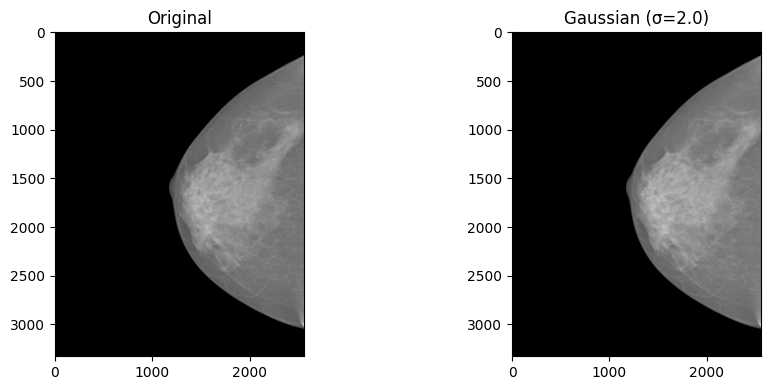

In [22]:
output = img.clone()
Filters.gaussian_filter(img, output, sigma=2.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Gaussian (σ=2.0)")
plt.tight_layout()
plt.show()

## 2. Median Filter

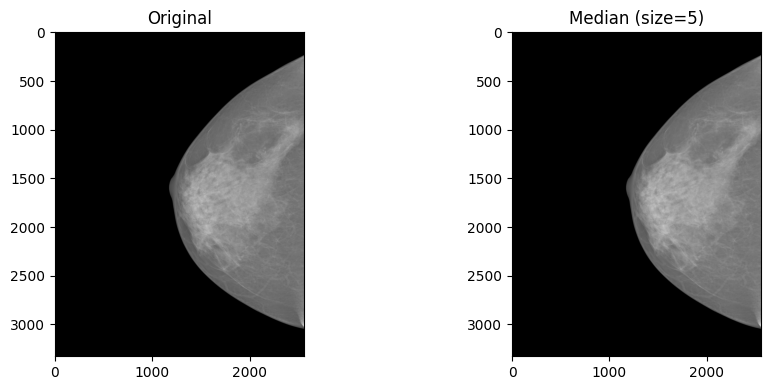

In [23]:
output = img.clone()
Filters.median_filter(img, output, size=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy().squeeze(), cmap="gray")
axes[1].set_title("Median (size=5)")
plt.tight_layout()
plt.show()

## 3. Difference of Gaussians (DoG)

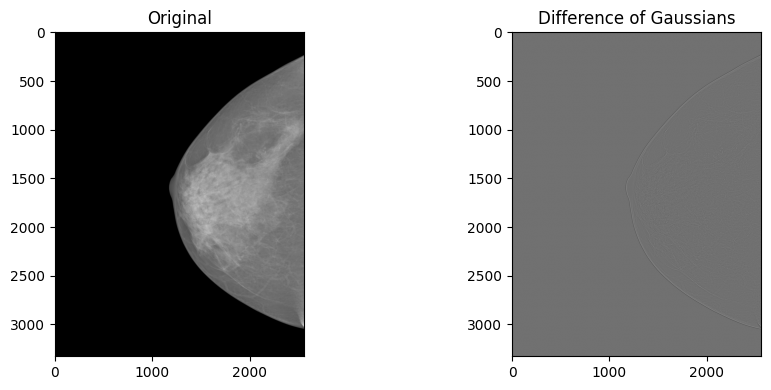

In [24]:
output = img.clone()
Filters.difference_of_gaussian(img, output, low_sigma=1.0, high_sigma=2.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Difference of Gaussians")
plt.tight_layout()
plt.show()

## 4. Gamma Correction

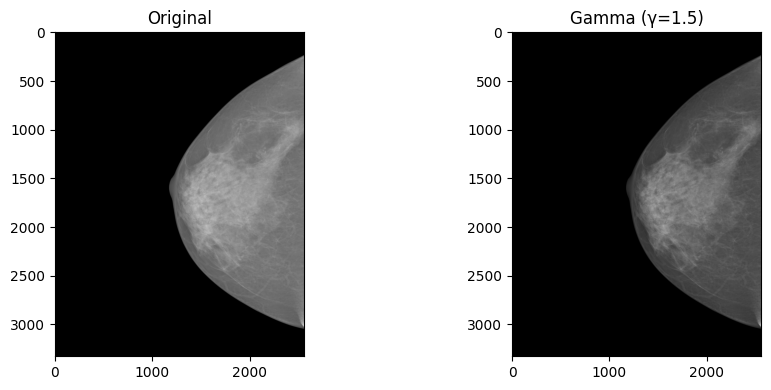

In [25]:
output = img.clone()
Filters.gamma_correction(img, output, gamma=1.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Gamma (γ=1.5)")
plt.tight_layout()
plt.show()

## 5. Otsu Thresholding

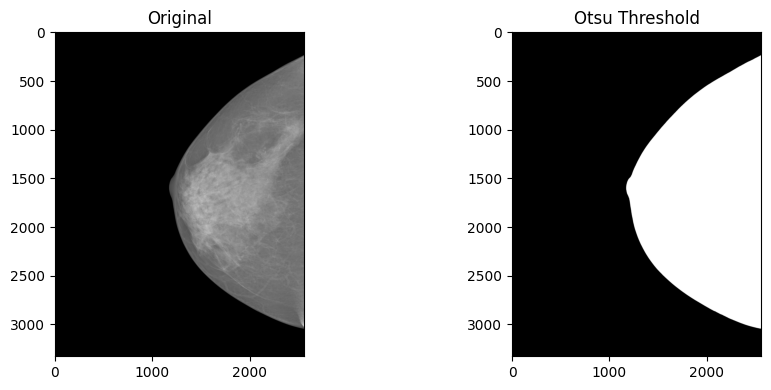

In [26]:
output = img.clone()
Threshold.otsu_threshold(img, output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("Otsu Threshold")
plt.tight_layout()
plt.show()

## 6. Sauvola Thresholding (Adaptive)

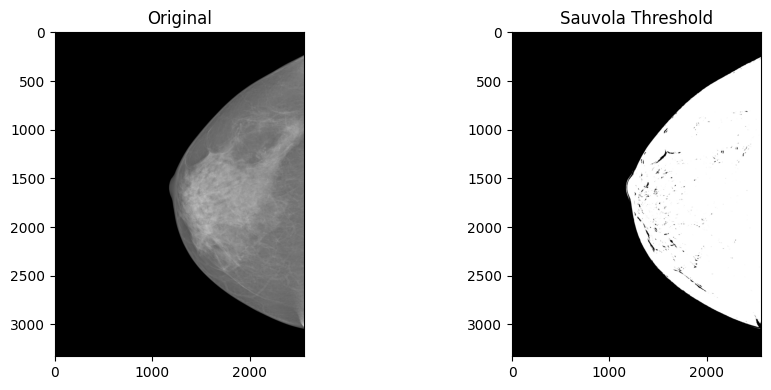

In [27]:
output = img.clone()
Threshold.sauvola_threshold(img, output, window_size=25, k=0.2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("Sauvola Threshold")
plt.tight_layout()
plt.show()

## 7. Morphology Operations

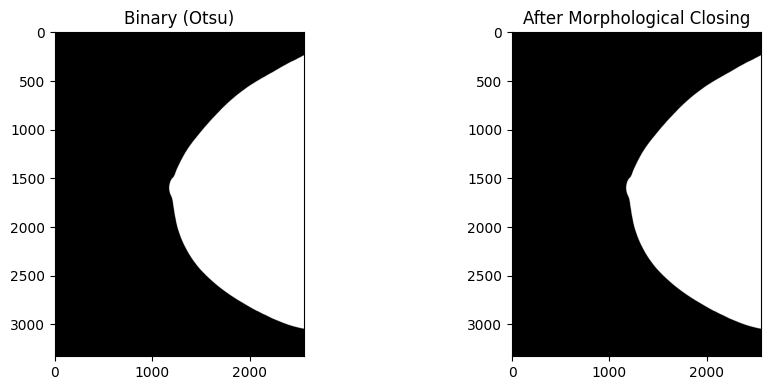

In [28]:
binary = img.clone()
Threshold.otsu_threshold(img, binary)

closed = binary.clone()
MorphologyOperations.morphology_closing(binary, closed, kernel_size=7)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(binary.pixel_data.cpu().numpy(), cmap="gray")
axes[0].set_title("Binary (Otsu)")
axes[1].imshow(closed.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("After Morphological Closing")
plt.tight_layout()
plt.show()

## 8. Top-Hat Transform

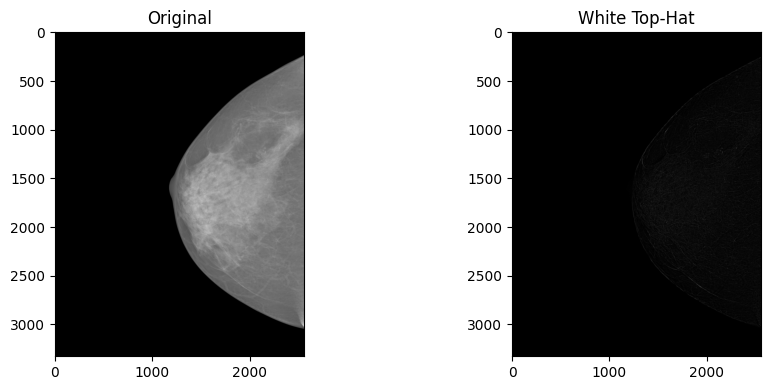

In [29]:
output = img.clone()
MorphologyOperations.white_top_hat(img, output, radius=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("White Top-Hat")
plt.tight_layout()
plt.show()

## 9. FFT (Frequency Domain)

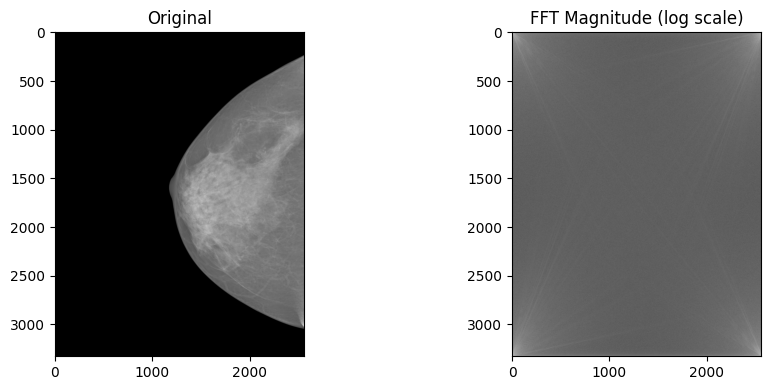

In [30]:
output = img.clone()
FrequencyOperations.fft(img, output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.log1p(np.abs(output.pixel_data.numpy())), cmap="gray")
axes[1].set_title("FFT Magnitude (log scale)")
plt.tight_layout()
plt.show()

## 11. Built-in Algorithms

In [33]:
from medical_image import FebdsAlgorithm, KMeansAlgorithm, FCMAlgorithm, TopHatAlgorithm

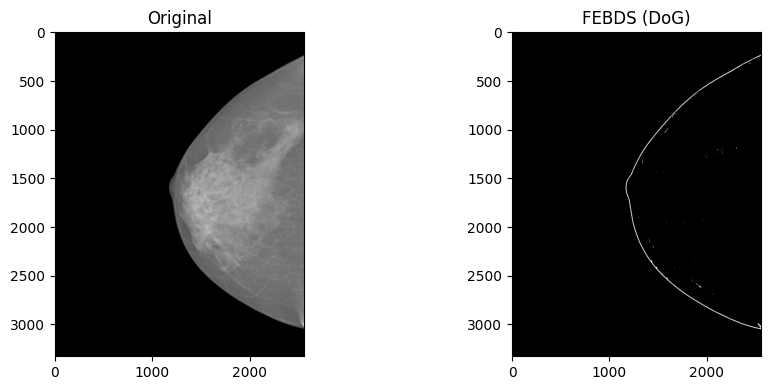

In [34]:
# FEBDS Algorithm (Difference of Gaussians variant)
img_t = img.clone()
output = img_t.clone()
algo = FebdsAlgorithm(method="dog", device="cpu")
algo(image=img_t, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(
    output.pixel_data.detach().cpu().numpy().reshape(img.height, img.width), cmap="gray"
)
axes[1].set_title("FEBDS (DoG)")
plt.tight_layout()
plt.show()

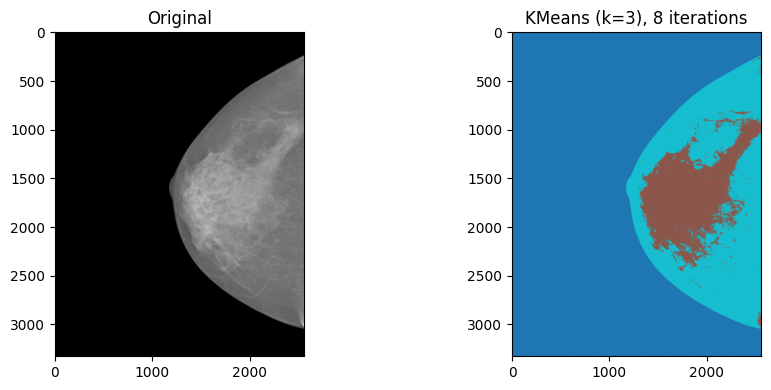

In [35]:
# KMeans Clustering
output = img.clone()
kmeans = KMeansAlgorithm(k=3, device="cpu")
kmeans(image=img, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(kmeans.labels.numpy(), cmap="tab10")
axes[1].set_title(f"KMeans (k=3), {kmeans.n_iter} iterations")
plt.tight_layout()
plt.show()

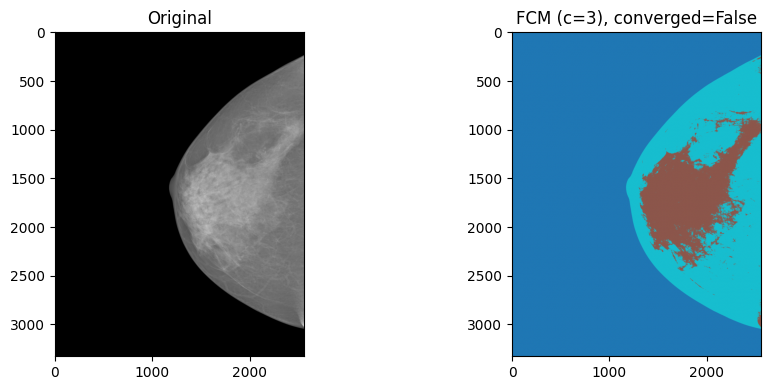

In [36]:
# Fuzzy C-Means
output = img.clone()
fcm = FCMAlgorithm(c=3, device="cpu")
fcm(image=img, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(fcm.labels.numpy(), cmap="tab10")
axes[1].set_title(f"FCM (c=3), converged={fcm.converged}")
plt.tight_layout()
plt.show()

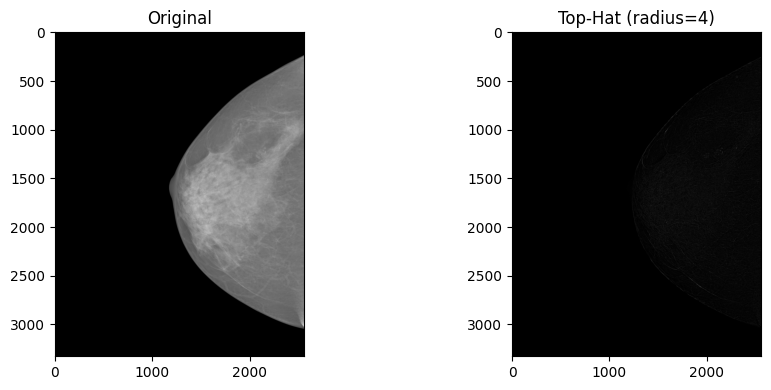

In [37]:
# Top-Hat Algorithm
output = img.clone()
tophat = TopHatAlgorithm(radius=4, device="cpu")
tophat(image=img, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("Top-Hat (radius=4)")
plt.tight_layout()
plt.show()